In [7]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Setup

In [8]:
import numpy as np
import torch
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import build_optimizer, fit_2D, fit_2d_per_slice
from utils.loss_functions import vae_loss
from models.alzheimers_cure_2d import VAE
from models.no_more_alzheimer_2d import UNet2D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [9]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


Display the middle slice of the dataset

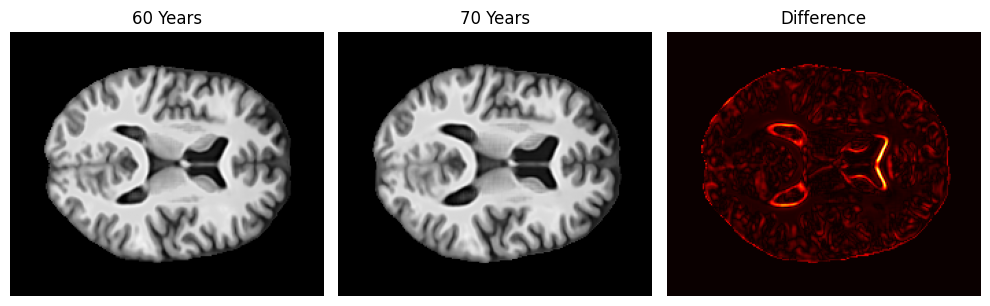

In [10]:
middle_h3 = data_loader.get_slice(training_pairs[100][0], index=90)
middle_h4 = data_loader.get_slice(training_pairs[100][1], index=90)

difference = np.abs(middle_h3 - middle_h4)
data_loader.display_slices([middle_h3, middle_h4, difference], ["60 Years", "70 Years", "Difference"], slice_colors=["gray", "gray", "hot"])

## One model for whole brain

In [11]:
# Load VAE and optimizer
vae = VAE(latent_dim=64).to(device)
vae_optimizer = build_optimizer(vae, lr=1e-4, wd=1e-4)

# Load UNET and optimizer
unet = UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)
unet_optimizer = build_optimizer(unet, lr=1e-4, wd=1e-4)

In [ ]:
_, vae_snapshots = fit_2D(vae, 
                            device,
                            data_loader,
                            training_pairs, 
                            vae_loss, 
                            optimizer=vae_optimizer, 
                            epochs=1001, 
                            print_every=200, 
                            save_every=200,
                            )

Saved snapshot for pair 0 at slice idx 90
Saved snapshot for pair 20 at slice idx 90
Saved snapshot for pair 40 at slice idx 90
Saved snapshot for pair 60 at slice idx 90
Saved snapshot for pair 80 at slice idx 90
Saved snapshot for pair 100 at slice idx 90
Saved snapshot for pair 120 at slice idx 90
Saved snapshot for pair 140 at slice idx 90
Saved snapshot for pair 160 at slice idx 90
Saved snapshot for pair 180 at slice idx 90
Saved snapshot for pair 200 at slice idx 90


In [ ]:
_, unet_snapshots = fit_2D(unet, 
                            device,
                            data_loader,
                            training_pairs, 
                            vae_loss, 
                            optimizer=unet_optimizer, 
                            epochs=1001, 
                            print_every=200, 
                            save_every=200,
                            )

Saved snapshot for pair 0 at slice idx 90
Saved snapshot for pair 20 at slice idx 90
Saved snapshot for pair 40 at slice idx 90
Saved snapshot for pair 60 at slice idx 90
Saved snapshot for pair 80 at slice idx 90
Saved snapshot for pair 100 at slice idx 90
Saved snapshot for pair 120 at slice idx 90
Saved snapshot for pair 140 at slice idx 90
Saved snapshot for pair 160 at slice idx 90
Saved snapshot for pair 180 at slice idx 90
Saved snapshot for pair 200 at slice idx 90


Displaying comparison for iteration 0 (U-Net) vs 0 (VAE)


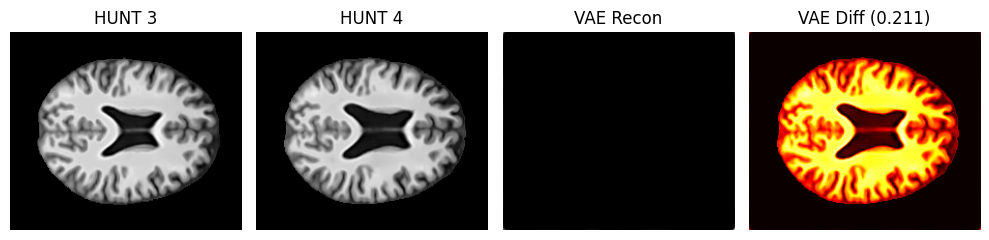

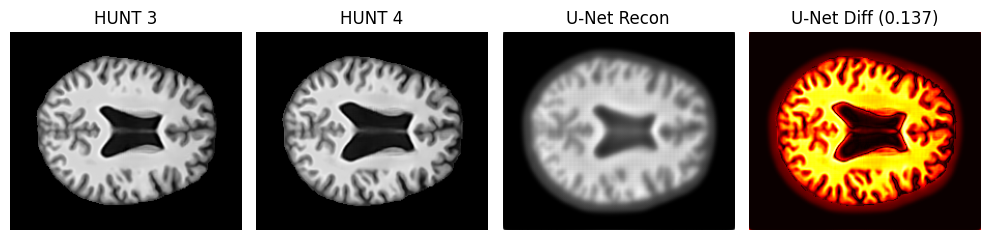

Displaying comparison for iteration 20 (U-Net) vs 20 (VAE)


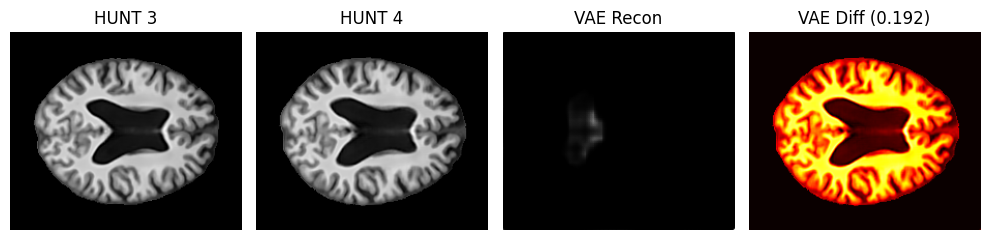

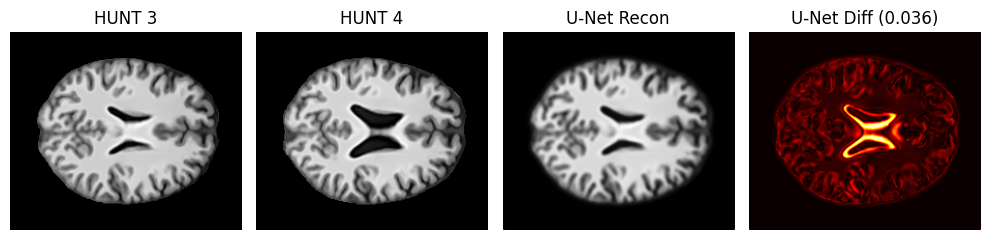

Displaying comparison for iteration 40 (U-Net) vs 40 (VAE)


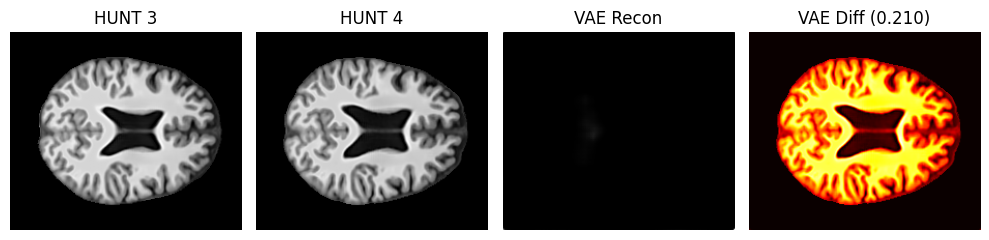

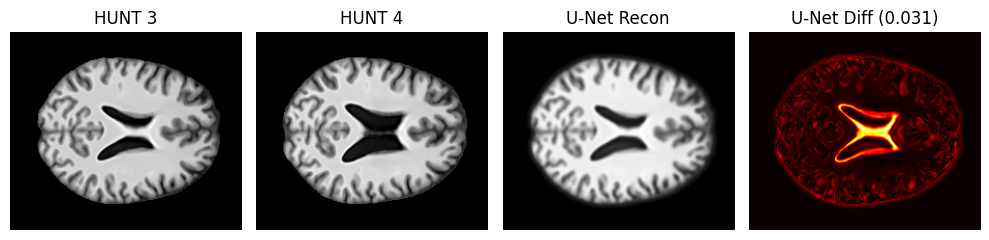

Displaying comparison for iteration 60 (U-Net) vs 60 (VAE)


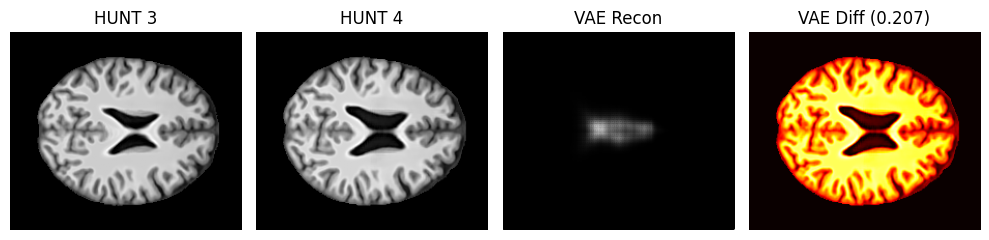

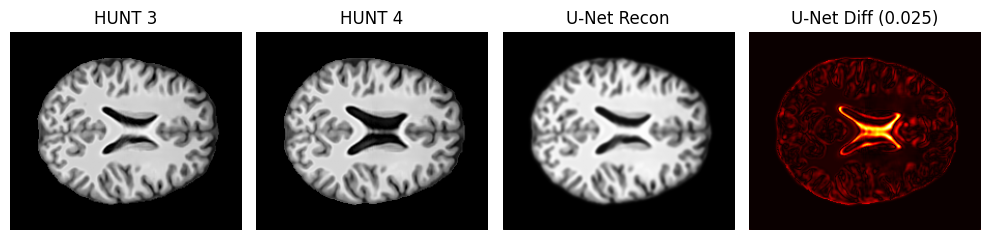

Displaying comparison for iteration 80 (U-Net) vs 80 (VAE)


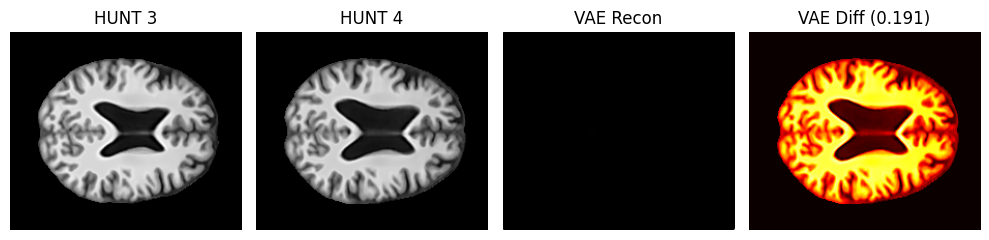

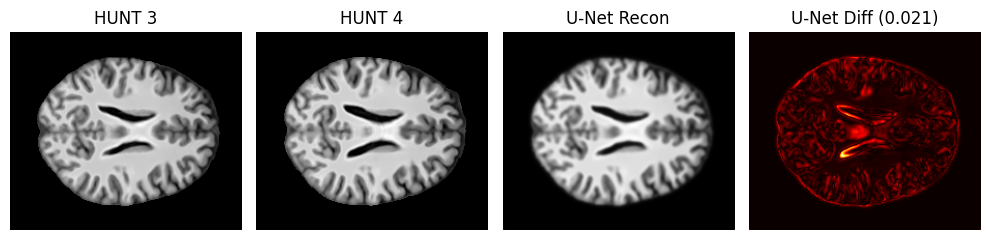

Displaying comparison for iteration 100 (U-Net) vs 100 (VAE)


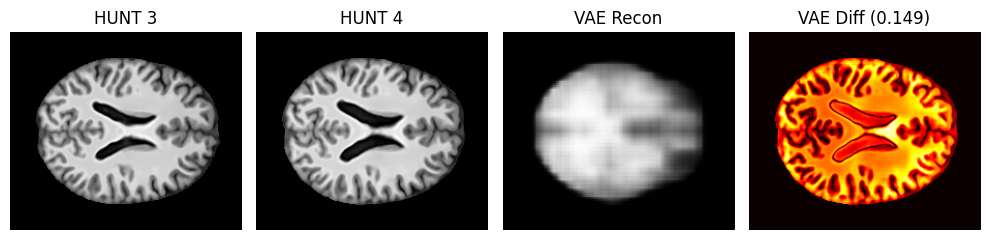

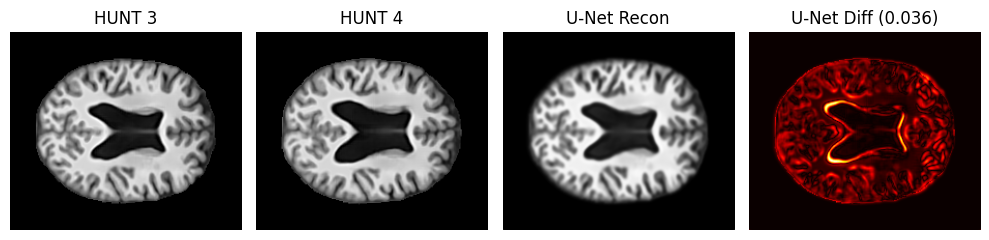

Displaying comparison for iteration 120 (U-Net) vs 120 (VAE)


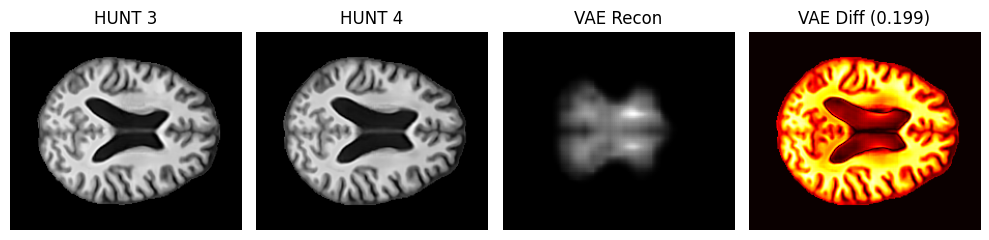

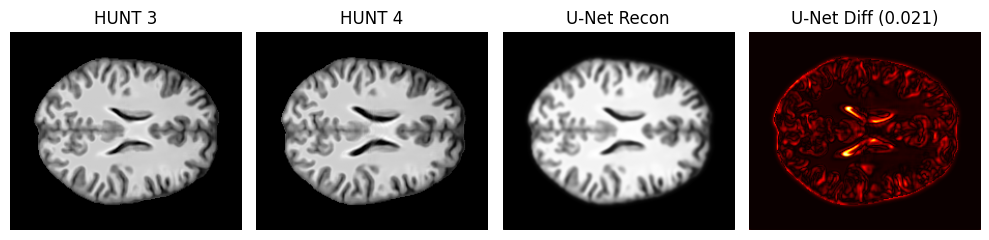

Displaying comparison for iteration 140 (U-Net) vs 140 (VAE)


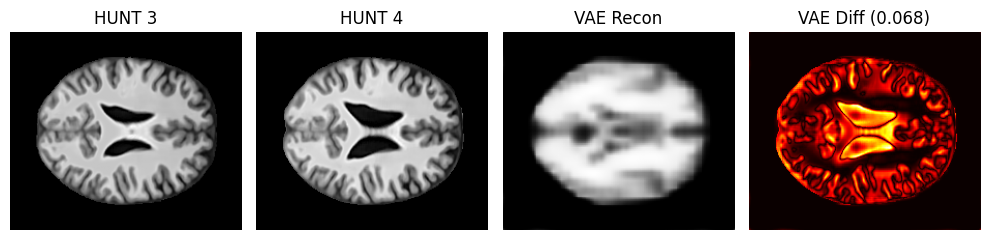

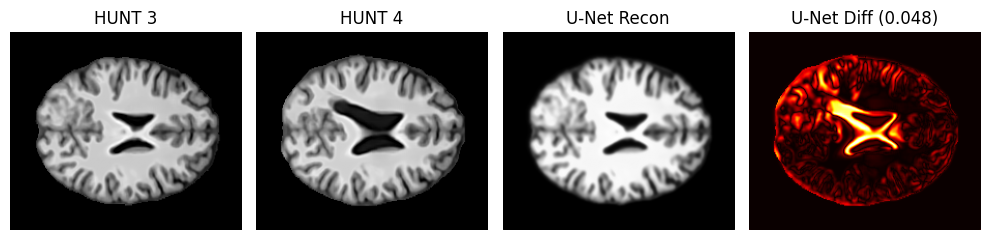

Displaying comparison for iteration 160 (U-Net) vs 160 (VAE)


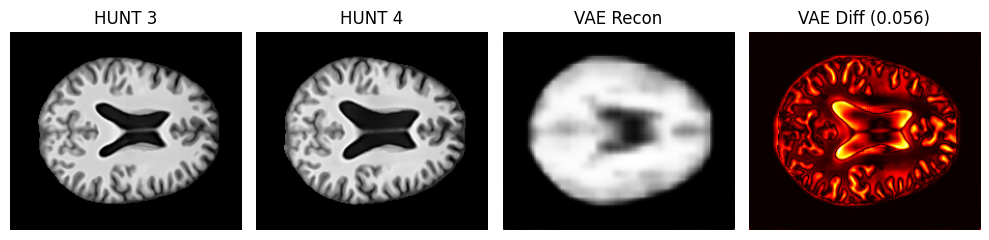

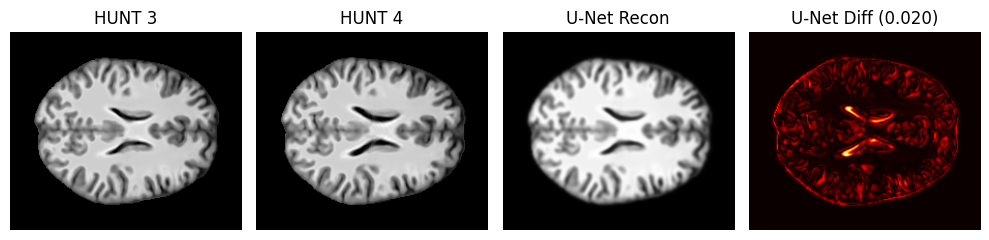

Displaying comparison for iteration 180 (U-Net) vs 180 (VAE)


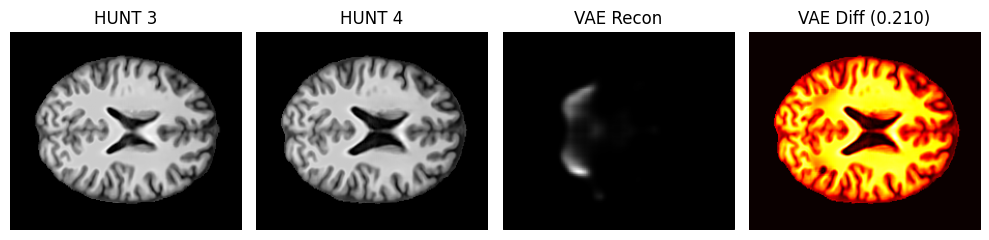

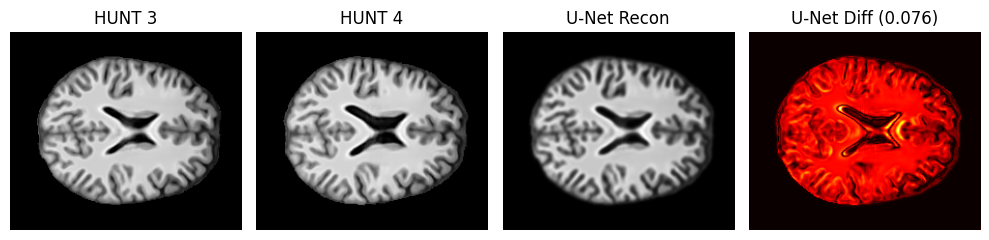

Displaying comparison for iteration 200 (U-Net) vs 200 (VAE)


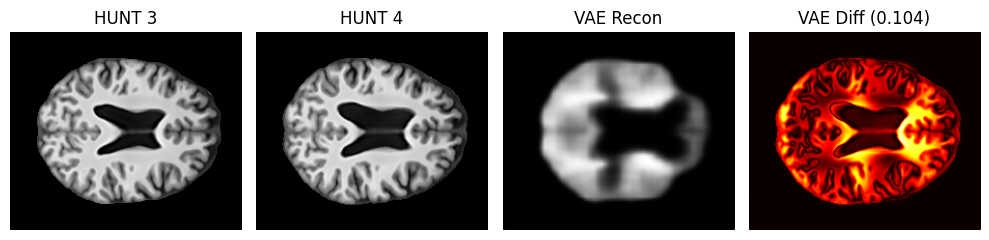

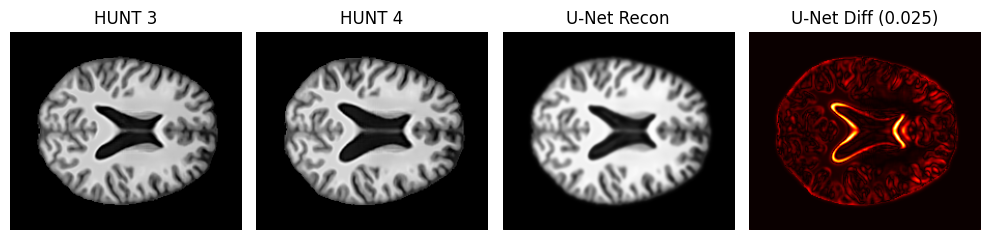

In [14]:
# Make sure both have the same number of snapshots
for unet_snap, vae_snap in zip(unet_snapshots, vae_snapshots):
    print(f"Displaying comparison for iteration {unet_snap['iter']} (U-Net) vs {vae_snap['iter']} (VAE)")

    # Compute absolute difference maps
    diff_unet = np.abs(unet_snap["recon"] - unet_snap["y"])
    diff_vae = np.abs(vae_snap["recon"] - vae_snap["y"])

    # Prepare slices — U-Net on top, VAE below
    vae_slices = [vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae]
    unet_slices = [unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet]

    slices = [
        unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet,
        vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae
    ]

    unet_labels = ["HUNT 3", "HUNT 4", "U-Net Recon", f"U-Net Diff ({np.mean(diff_unet):.3f})"]
    vae_labels = ["HUNT 3", "HUNT 4", "VAE Recon", f"VAE Diff ({np.mean(diff_vae):.3f})"]
    
    colors = ["gray", "gray", "gray", "hot"]

    # Display slices on top of each other
    data_loader.display_slices(vae_slices, slice_labels=vae_labels, slice_colors=colors)
    data_loader.display_slices(unet_slices, slice_labels=unet_labels, slice_colors=colors)


## One model per Slice Index

In [15]:
# Load VAE and optimizer
vae_models = [VAE(latent_dim=64).to(device)] * 193
vae_optimizers = [build_optimizer(vae, lr=1e-4, wd=1e-4) for vae in vae_models]

# Load UNET and optimizer
unet_models = [UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)] * 193
unet_optimizers = [build_optimizer(unet, lr=1e-4, wd=1e-4) for unet in unet_models]

In [ ]:
_, multi_vae_snapshots = fit_2d_per_slice(
    vae_models,
    device,
    data_loader,
    training_pairs,
    vae_loss,
    optimizers=vae_optimizers,
    epochs=1001,
    print_every=200,
    save_every=200,
)

[Epoch 0] avg_loss=0.3138 | bce=0.2992 | kld=14.6094 | slices=193
Saved snapshot at epoch 0 for slice 96
[Epoch 20] avg_loss=0.1715 | bce=0.1705 | kld=0.9722 | slices=193
Saved snapshot at epoch 20 for slice 96
[Epoch 40] avg_loss=0.1704 | bce=0.1692 | kld=1.1926 | slices=193
Saved snapshot at epoch 40 for slice 96
[Epoch 60] avg_loss=0.1649 | bce=0.1640 | kld=0.9245 | slices=193
Saved snapshot at epoch 60 for slice 96
[Epoch 80] avg_loss=0.1679 | bce=0.1668 | kld=1.0915 | slices=193
Saved snapshot at epoch 80 for slice 96
[Epoch 100] avg_loss=0.1698 | bce=0.1686 | kld=1.1829 | slices=193
Saved snapshot at epoch 100 for slice 96
[Epoch 120] avg_loss=0.1654 | bce=0.1643 | kld=1.1702 | slices=193
Saved snapshot at epoch 120 for slice 96
[Epoch 140] avg_loss=0.1665 | bce=0.1654 | kld=1.1074 | slices=193
Saved snapshot at epoch 140 for slice 96
[Epoch 160] avg_loss=0.1645 | bce=0.1633 | kld=1.2330 | slices=193
Saved snapshot at epoch 160 for slice 96
[Epoch 180] avg_loss=0.1624 | bce=0.160

In [ ]:
_, multi_unet_snapshots = fit_2d_per_slice(
    unet_models,
    device,
    data_loader,
    training_pairs,
    vae_loss,
    optimizers=unet_optimizers,
    epochs=1001,
    print_every=200,
    save_every=200,
)

[Epoch 0] avg_loss=0.3959 | bce=0.3959 | kld=0.0004 | slices=193
Saved snapshot at epoch 0 for slice 96
[Epoch 20] avg_loss=0.1537 | bce=0.1537 | kld=0.0000 | slices=193
Saved snapshot at epoch 20 for slice 96
[Epoch 40] avg_loss=0.1560 | bce=0.1560 | kld=0.0000 | slices=193
Saved snapshot at epoch 40 for slice 96
[Epoch 60] avg_loss=0.1547 | bce=0.1547 | kld=0.0000 | slices=193
Saved snapshot at epoch 60 for slice 96
[Epoch 80] avg_loss=0.1554 | bce=0.1554 | kld=0.0000 | slices=193
Saved snapshot at epoch 80 for slice 96
[Epoch 100] avg_loss=0.1558 | bce=0.1558 | kld=0.0000 | slices=193
Saved snapshot at epoch 100 for slice 96
[Epoch 120] avg_loss=0.1597 | bce=0.1597 | kld=0.0000 | slices=193
Saved snapshot at epoch 120 for slice 96
[Epoch 140] avg_loss=0.1581 | bce=0.1581 | kld=0.0000 | slices=193
Saved snapshot at epoch 140 for slice 96
[Epoch 160] avg_loss=0.1577 | bce=0.1577 | kld=0.0000 | slices=193
Saved snapshot at epoch 160 for slice 96
[Epoch 180] avg_loss=0.1628 | bce=0.1628

Epoch 0: U-Net slice=96 | VAE slice=96


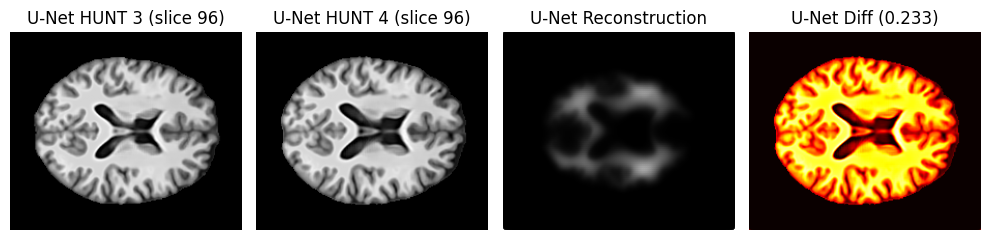

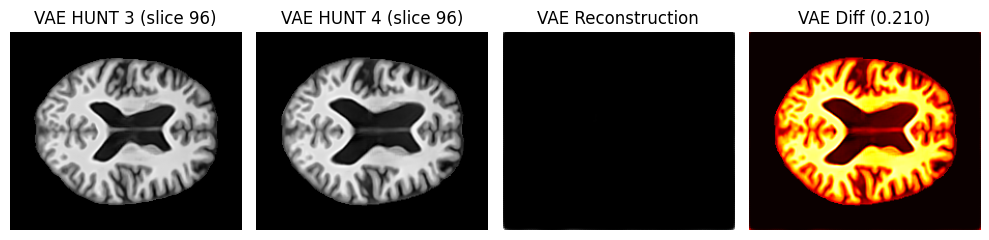

Epoch 20: U-Net slice=96 | VAE slice=96


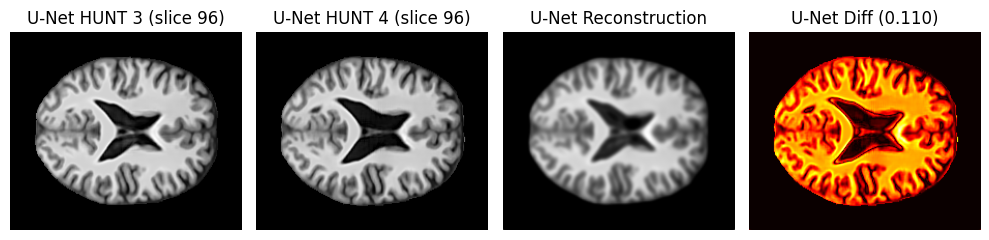

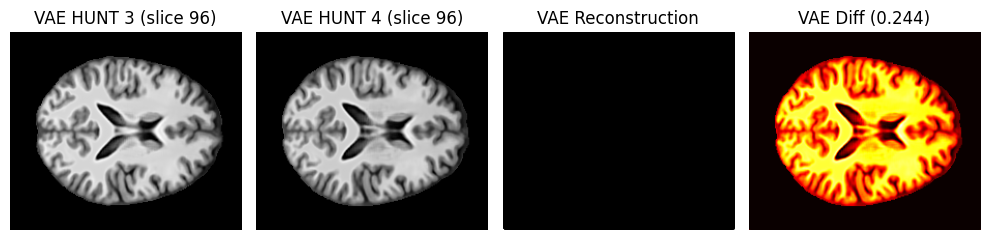

Epoch 40: U-Net slice=96 | VAE slice=96


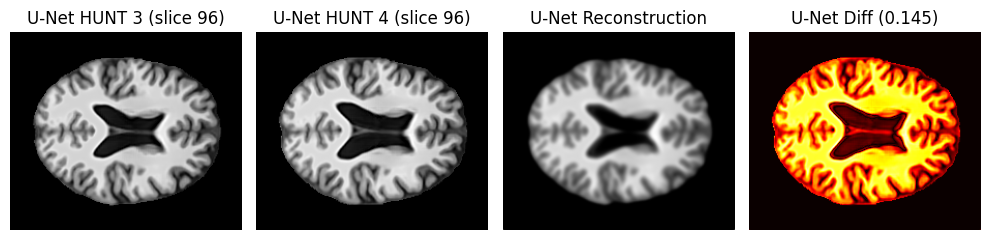

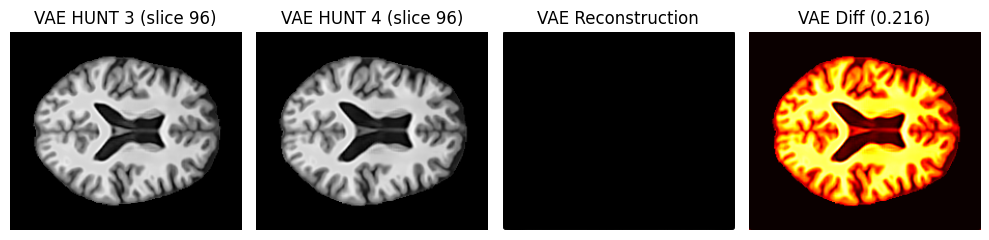

Epoch 60: U-Net slice=96 | VAE slice=96


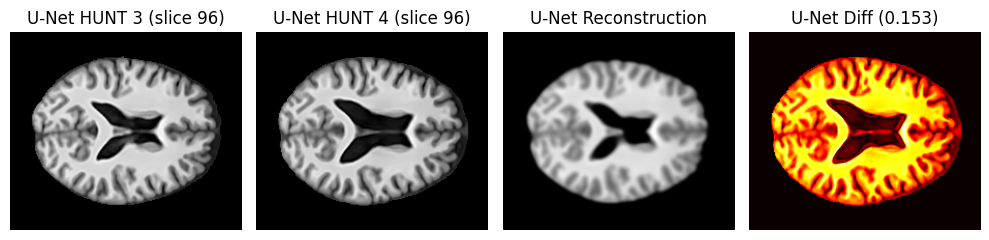

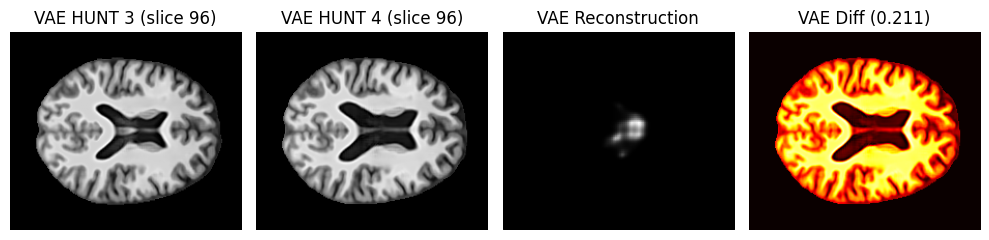

Epoch 80: U-Net slice=96 | VAE slice=96


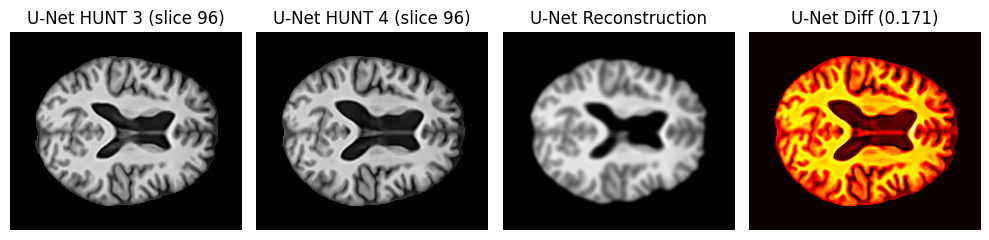

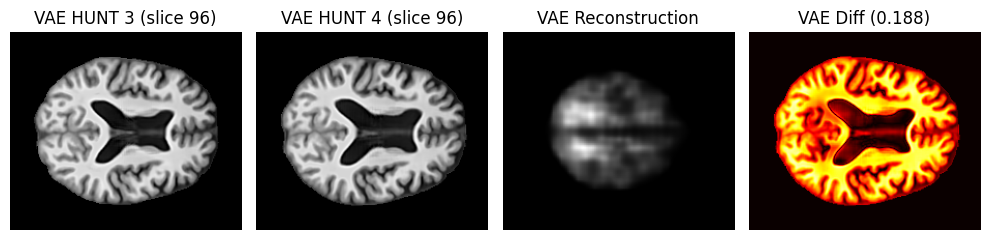

Epoch 100: U-Net slice=96 | VAE slice=96


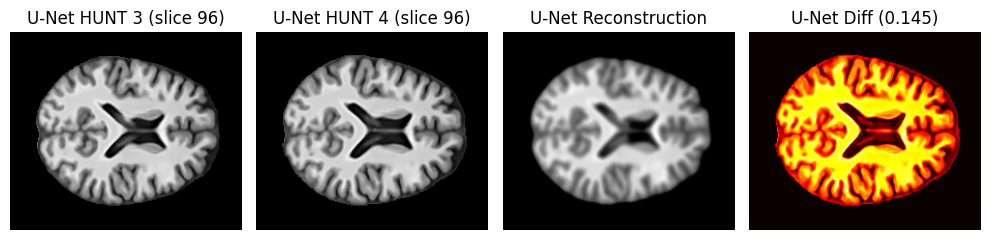

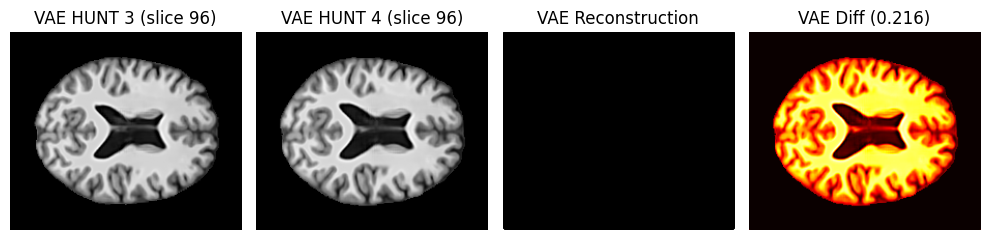

Epoch 120: U-Net slice=96 | VAE slice=96


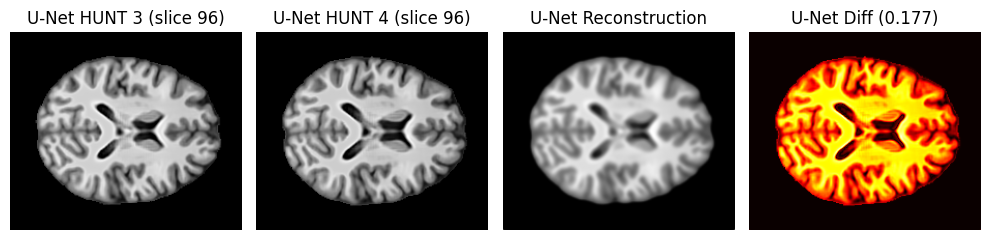

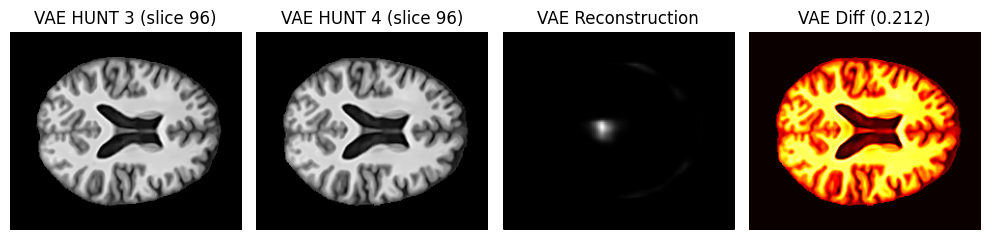

Epoch 140: U-Net slice=96 | VAE slice=96


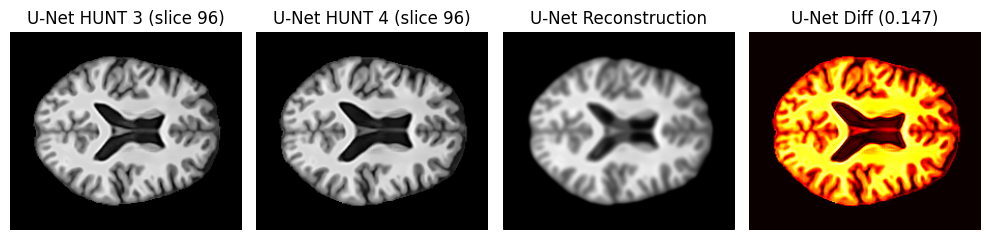

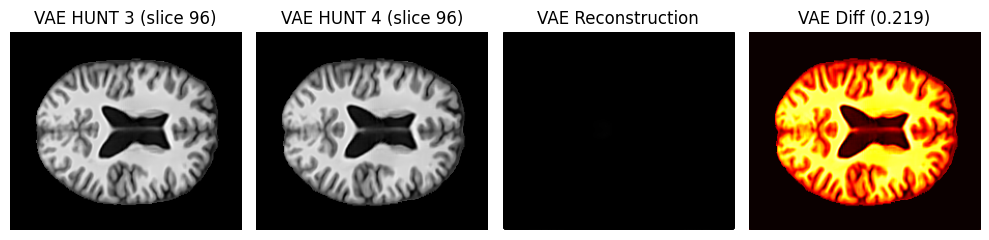

Epoch 160: U-Net slice=96 | VAE slice=96


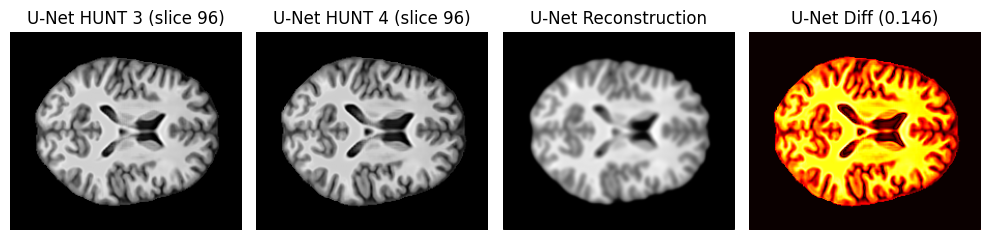

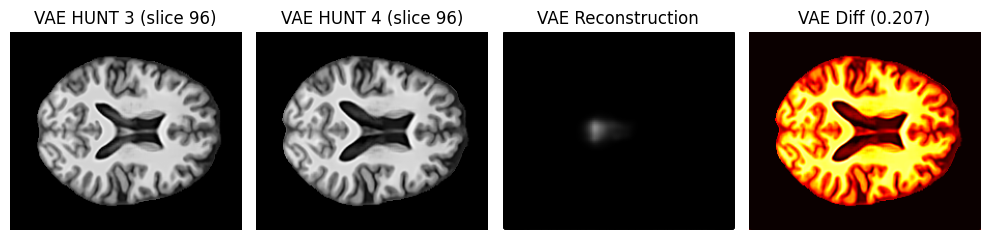

Epoch 180: U-Net slice=96 | VAE slice=96


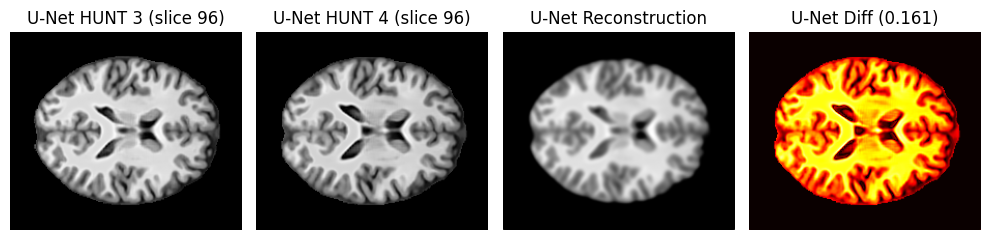

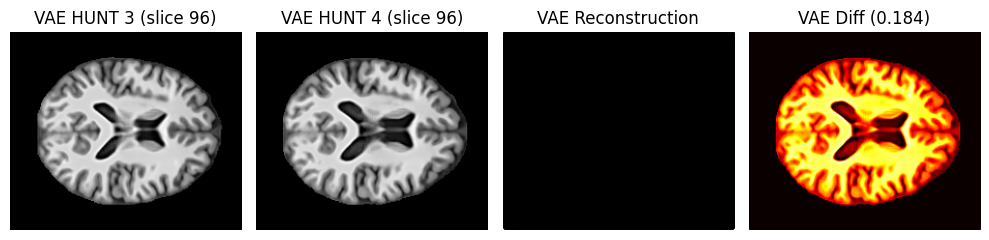

Epoch 200: U-Net slice=96 | VAE slice=96


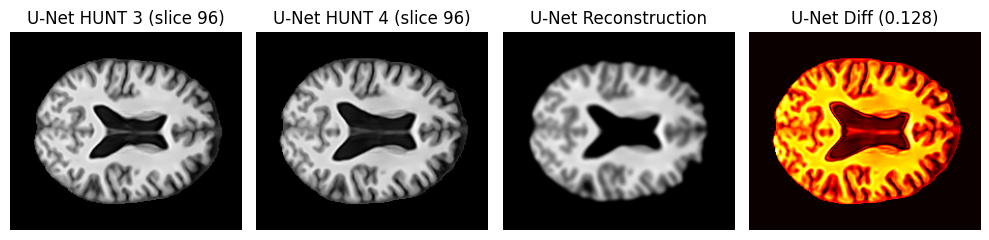

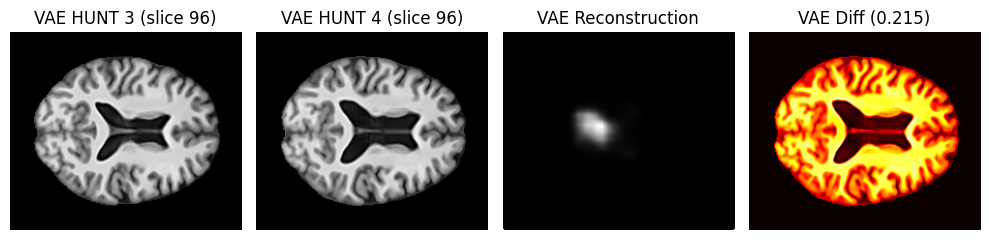

In [19]:
import random
import numpy as np
from collections import defaultdict

def _group_by_epoch(snaps):
    by_epoch = defaultdict(list)  # epoch -> [snapshots]
    for s in snaps:
        ep = s.get("iter", None)
        if ep is not None:
            by_epoch[ep].append(s)
    return by_epoch

u_by_epoch = _group_by_epoch(multi_unet_snapshots)
v_by_epoch = _group_by_epoch(multi_vae_snapshots)

# Only show epochs present in BOTH sets
common_epochs = sorted(set(u_by_epoch.keys()) & set(v_by_epoch.keys()))
if not common_epochs:
    raise RuntimeError("No overlapping epochs between U-Net and VAE snapshots.")

for ep in common_epochs:
    # Pick a random snapshot (slice/model) from this epoch for each type
    unet_snap = random.choice(u_by_epoch[ep])
    vae_snap  = random.choice(v_by_epoch[ep])

    print(f"Epoch {ep}: U-Net slice={unet_snap.get('slice_idx','?')} | VAE slice={vae_snap.get('slice_idx','?')}")

    # Differences
    diff_unet = np.abs(unet_snap["recon"] - unet_snap["y"])
    diff_vae  = np.abs(vae_snap["recon"]  - vae_snap["y"])

    # Prepare rows: U-Net (top), VAE (bottom)
    colors = ["gray", "gray", "gray", "hot"]

    unet_slices = [unet_snap["x"], unet_snap["y"], unet_snap["recon"], diff_unet]
    unet_labels = [
        f"U-Net HUNT 3 (slice {unet_snap.get('slice_idx','?')})",
        f"U-Net HUNT 4 (slice {unet_snap.get('slice_idx','?')})",
        "U-Net Reconstruction",
        f"U-Net Diff ({np.mean(diff_unet):.3f})",
    ]

    vae_slices = [vae_snap["x"], vae_snap["y"], vae_snap["recon"], diff_vae]
    vae_labels = [
        f"VAE HUNT 3 (slice {vae_snap.get('slice_idx','?')})",
        f"VAE HUNT 4 (slice {vae_snap.get('slice_idx','?')})",
        "VAE Reconstruction",
        f"VAE Diff ({np.mean(diff_vae):.3f})",
    ]

    # Stack vertically (two calls = two rows)
    data_loader.display_slices(unet_slices, slice_labels=unet_labels, slice_colors=colors)
    data_loader.display_slices(vae_slices,  slice_labels=vae_labels,  slice_colors=colors)
